# Model C Development (Logistic Regression)

## 1. Setup

In [2]:
import pandas as pd
import os
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    classification_report
)

## 2. Data Loading

In [3]:
input_path = Path("../data/processed/dataset_final.csv")
df = pd.read_csv(input_path)
print("Data loaded. Shape:", df.shape)
display(df.head())

Data loaded. Shape: (1200, 41)


,transaction_type_online purchase,transaction_type_transfer,transaction_type_withdrawal,merchant_category_Clothing,merchant_category_Crypto,merchant_category_Electronics,merchant_category_Entertainment,merchant_category_Food,merchant_category_Gambling,merchant_category_Services,...,account_age_days,description_risk_score,transaction_frequency_24h,num_failed_transactions_7d,transaction_hour,is_weekend,num_devices_used,num_countries_used,kyc_verified,is_fraud
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.929790,-0.368841,0.0,0.0,8.0,0.0,2.0,0.0,0.0,0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.761706,-0.368841,0.0,0.0,7.0,0.0,2.0,0.0,1.0,0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.964482,-0.368841,0.0,0.0,19.0,0.0,1.0,0.0,0.0,1
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,-0.560900,3.310755,0.0,0.0,3.0,0.0,1.0,1.0,1.0,1
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-1.064750,-0.368841,0.0,0.0,10.0,0.0,2.0,0.0,0.0,0


## 3. Data Preparation

In [4]:
# The dataset_final.csv is already largely preprocessed.
# Below are typical data preparation steps that would be applied
# if starting from raw data, but are largely for documentation here
# as the input CSV is already in a suitable format.

# 1. Feature Selection / Dropping Irrelevant Columns
# These columns are typically dropped if present, but may already be absent
# in the preprocessed 'dataset_final.csv'.
cols_to_drop = [
    'transaction_id', 'timestamp', 'customer_id',
    'transaction_description', 'merchant_name', 'customer_support_note',
    'risk_category'
 ]
df_clean = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Encoding Categorical Variables
# Assuming one-hot encoding has already been applied upstream to create dataset_final.csv.
# If not, a step like the following would be needed:
# df_encoded = pd.get_dummies(df_clean, drop_first=True)
# For this notebook, df_clean is already df_encoded as per dataset_final.csv structure.
X_features = df_clean.copy() # Use df_clean as the basis for features

In [5]:
# 3. Split X (Features) and y (Target)
X = X_features.drop('is_fraud', axis=1) # Drop the target from the features
y = df['is_fraud']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (960, 40)
Testing set shape: (240, 40)


## 4. Model Training

In [7]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## 5. Model Evaluation

In [8]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8333
ROC-AUC: 0.6683

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.98      0.90       188
           1       0.80      0.31      0.44        52

    accuracy                           0.83       240
   macro avg       0.82      0.64      0.67       240
weighted avg       0.83      0.83      0.80       240



## 6. Save Results

In [9]:
model_name = "Logistic Regression"
output_file = "../results/model_c_results.csv"

# Calculate metrics
metrics = {
    'model': model_name,
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob)
}

# Create DataFrame
results_df = pd.DataFrame([metrics])

# Ensure directory exists
os.makedirs(os.path.dirname(output_file), exist_ok=True)

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"Results for {model_name} saved to {output_file}")

Results for Logistic Regression saved to ../results/model_c_results.csv



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Computing feature importance from Logistic Regression model (coefficients) ...
Top 10 features by absolute coefficient:


,Feature,Coefficient,Importance
0,description_risk_score,1.075492,1.075492
1,description_tone_routine,-1.057143,1.057143
2,merchant_category_Food,-0.721927,0.721927
3,description_tone_urgent,0.584547,0.584547
4,merchant_category_Crypto,0.534707,0.534707
5,merchant_category_Utilities,0.519152,0.519152
6,description_tone_panic,0.457537,0.457537
7,semantic_merchant_category_services,-0.455437,0.455437
8,kyc_verified,0.453004,0.453004
9,transaction_type_withdrawal,-0.426890,0.426890


Saved feature importance to '../results/model_c_feature_importance.csv'


C:\Users\mdani\AppData\Local\Temp\ipykernel_17400\1576899641.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(10), palette='viridis')


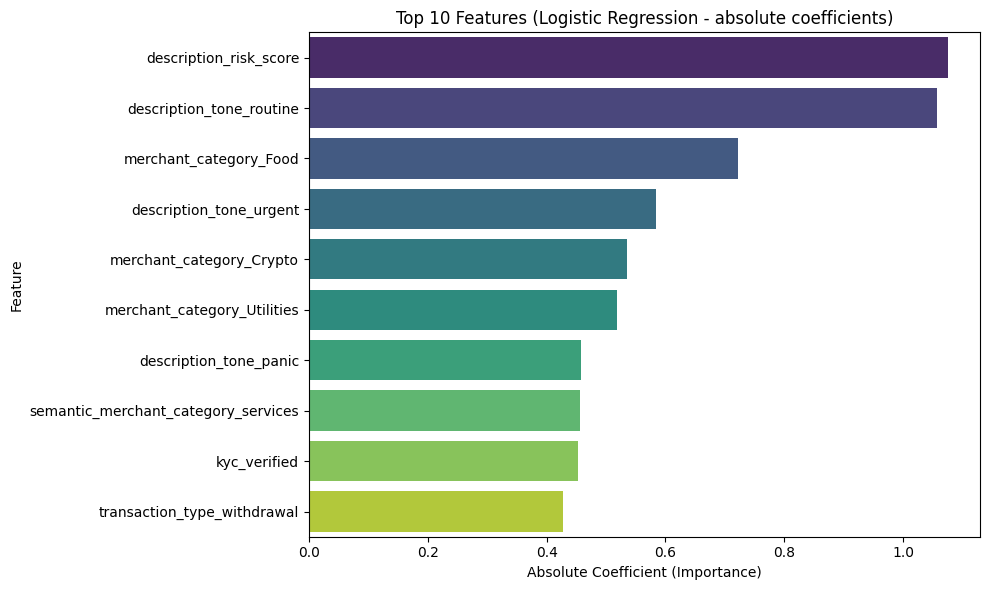

In [11]:
# 6a. Feature Importance (Logistic Regression coefficients)
import numpy as np
import matplotlib.pyplot as plt
!pip install seaborn
import seaborn as sns
from sklearn.inspection import permutation_importance

print("Computing feature importance from Logistic Regression model (coefficients) ...")
if hasattr(lr_model, "coef_"):
    coefs = lr_model.coef_[0]
    feature_names = X.columns
    importances = np.abs(coefs)
    fi_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    # Display top 10
    print("Top 10 features by absolute coefficient:")
    display(fi_df.head(10))

    # Save to results
    os.makedirs('../results', exist_ok=True)
    fi_df.to_csv('../results/model_c_feature_importance.csv', index=False)
    print("Saved feature importance to '../results/model_c_feature_importance.csv'")

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=fi_df.head(10), palette='viridis')
    plt.title('Top 10 Features (Logistic Regression - absolute coefficients)')
    plt.xlabel('Absolute Coefficient (Importance)')
    plt.tight_layout()
    plt.show()

else:
    print("Model has no coefficients; falling back to permutation importance.")
    perm = permutation_importance(lr_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': perm.importances_mean
    }).sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print("Top 10 features by permutation importance:")
    display(perm_df.head(10))

    os.makedirs('../results', exist_ok=True)
    perm_df.to_csv('../results/model_c_feature_importance.csv', index=False)
    print("Saved permutation importance to '../results/model_c_feature_importance.csv'")

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=perm_df.head(10), palette='viridis')
    plt.title('Top 10 Features (Permutation Importance)')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()

LLM PROMPT:

The columns of the dataset are as below:
transaction_type_online purchase	transaction_type_transfer	transaction_type_withdrawal	merchant_category_Clothing	merchant_category_Crypto	merchant_category_Electronics	merchant_category_Entertainment	merchant_category_Food	merchant_category_Gambling	merchant_category_Services	...	account_age_days	description_risk_score	transaction_frequency_24h	num_failed_transactions_7d	transaction_hour	is_weekend	num_devices_used	num_countries_used	kyc_verified	is_fraud

All of these are used to train a model to classify for fraud cases to differentiate if it is fraud or not.
After doing feature importance, the results obtained as as below, what can be concluded from the results of the feature importance?:



Feature	Coefficient	Importance
0	description_risk_score	1.075492	1.075492
1	description_tone_routine	-1.057143	1.057143
2	merchant_category_Food	-0.721927	0.721927
3	description_tone_urgent	0.584547	0.584547
4	merchant_category_Crypto	0.534707	0.534707
5	merchant_category_Utilities	0.519152	0.519152
6	description_tone_panic	0.457537	0.457537
7	semantic_merchant_category_services	-0.455437	0.455437
8	kyc_verified	0.453004	0.453004
9	transaction_type_withdrawal	-0.426890	0.426890


MODEL RESPONSE:
Key takeaways & actionable ideas 💡
The model strongly relies on text-derived signals (description risk score & tones), so continue validating the upstream text scoring process. If description_risk_score is derived from the target or downstream info, check for data leakage. ⚠️
Urgent/panic tones and crypto merchants are associated with higher fraud risk — consider targeted monitoring or additional verification (e.g., step-up auth) when these flags appear. ✅
Routine tone / food merchants / withdrawals appear safer in the model — these could be lower-priority for manual review or can influence rule thresholds.
The positive sign on kyc_verified is unexpected (we’d usually expect verification to lower fraud risk) — verify encoding (is 1 = verified?) and check for confounding (e.g., verified but high-volume business accounts with different patterns). 🔍